<a href="https://colab.research.google.com/github/DianaBravoPerez/EDP-1/blob/main/probabilidad_raices_reales_borrar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📐 Probabilidad de raíces reales en una ecuación cuadrática

**Problema:** Los coeficientes $p$ y $q$ de la ecuación
$$x^2 + px + q = 0$$
se toman **aleatoriamente** en el intervalo $(0, 2)$.

**¿Cuál es la probabilidad de que la ecuación tenga raíces reales?**

## Paso 1 — ¿Cuándo hay raíces reales?

Para que $x^2 + px + q = 0$ tenga raíces reales, el **discriminante** debe ser $\geq 0$:
$$\Delta = p^2 - 4q \geq 0$$

Despejando $q$:
$$\boxed{q \leq \frac{p^2}{4}}$$

Esa es nuestra **condición favorable**.

## Paso 2 — El espacio muestral (espacio total)

Como $p \in (0, 2)$ y $q \in (0, 2)$, el espacio muestral es un **cuadrado** de lado 2.

$$\text{Área total} = 2 \times 2 = 4$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

area_total = 2 * 2
print(f"Área total del espacio muestral = {area_total}")

Área total del espacio muestral = 4


## Paso 3 — Visualización de la región favorable

La región favorable es donde se cumple $q \leq \dfrac{p^2}{4}$ dentro del cuadrado $(0,2) \times (0,2)$.

Nota: la curva $q = p^2/4$ llega exactamente a la esquina $(2, 1)$, y nunca supera $q = 1 < 2$, así que **no hay necesidad de partir la integral en dos tramos**.

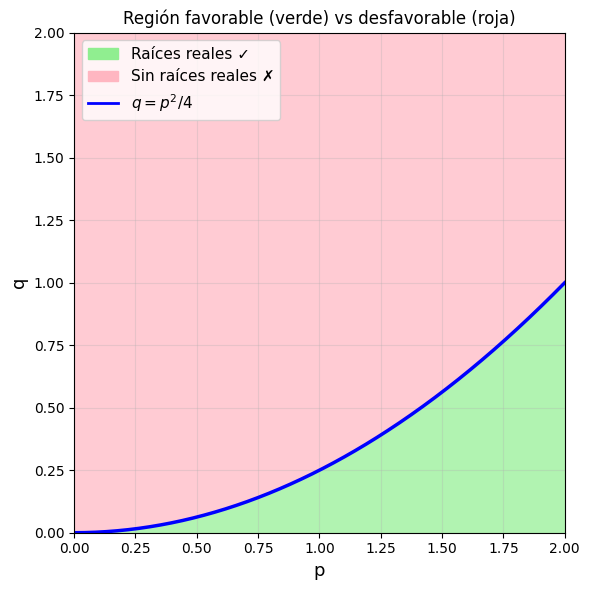

In [2]:
p_vals = np.linspace(0, 2, 500)
q_vals = np.linspace(0, 2, 500)
P, Q = np.meshgrid(p_vals, q_vals)

# Condición favorable: q <= p^2 / 4
condicion = Q <= (P**2) / 4

# Curva frontera
q_frontera = p_vals**2 / 4

fig, ax = plt.subplots(figsize=(6, 6))

ax.contourf(P, Q, condicion.astype(float),  levels=[0.5, 1.5], colors=['#90EE90'], alpha=0.7)
ax.contourf(P, Q, (~condicion).astype(float), levels=[0.5, 1.5], colors=['#FFB6C1'], alpha=0.7)
ax.plot(p_vals, q_frontera, 'b-', linewidth=2.5, label=r'$q = p^2/4$  (parábola)')

ax.set_xlabel('p', fontsize=13)
ax.set_ylabel('q', fontsize=13)
ax.set_title('Región favorable (verde) vs desfavorable (roja)', fontsize=12)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.grid(True, alpha=0.3)

verde = mpatches.Patch(color='#90EE90', label='Raíces reales ✓')
rojo  = mpatches.Patch(color='#FFB6C1', label='Sin raíces reales ✗')
curva = plt.Line2D([0],[0], color='blue', linewidth=2, label=r'$q = p^2/4$')
ax.legend(handles=[verde, rojo, curva], loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

## Paso 4 — Calcular el área favorable (integral)

Como la parábola $q = p^2/4$ en $p=2$ vale $q=1$, **siempre está por debajo de 2**, entonces:

$$A_{\text{favorable}} = \int_0^{2} \frac{p^2}{4}\, dp$$

Resolviendo:
$$A = \frac{1}{4} \cdot \frac{p^3}{3}\Bigg|_0^2 = \frac{1}{4} \cdot \frac{8}{3} = \frac{8}{12} = \frac{2}{3}$$

In [3]:
# Integral de 0 a 2 de p^2/4 dp
# Antiderivada: p^3 / 12
area_favorable = (2**3) / 12 - 0
print(f"Área favorable = 2³/12 = 8/12 = {area_favorable:.6f}")
print(f"En fracción    = 2/3 = {2/3:.6f}")

Área favorable = 2³/12 = 8/12 = 0.666667
En fracción    = 2/3 = 0.666667


## Paso 5 — Resultado analítico

$$P = \frac{A_{\text{favorable}}}{A_{\text{total}}} = \frac{2/3}{4} = \frac{2}{12} = \boxed{\frac{1}{6}}$$

In [4]:
probabilidad_analitica = area_favorable / area_total

print("=" * 40)
print("  RESULTADO ANALÍTICO")
print("=" * 40)
print(f"  P = (2/3) / 4 = 1/6")
print(f"  P = {probabilidad_analitica:.6f}")
print(f"  P ≈ {probabilidad_analitica*100:.4f}%")
print("=" * 40)

  RESULTADO ANALÍTICO
  P = (2/3) / 4 = 1/6
  P = 0.166667
  P ≈ 16.6667%


## Paso 6 — Verificación con Simulación Monte Carlo

In [5]:
np.random.seed(42)
N = 10_000_000

p_sim = np.random.uniform(0, 2, N)
q_sim = np.random.uniform(0, 2, N)

# Condición: q <= p^2 / 4
raices_reales = q_sim <= (p_sim**2) / 4
probabilidad_simulacion = raices_reales.mean()

print("=" * 40)
print("  VERIFICACIÓN MONTE CARLO")
print("=" * 40)
print(f"  Simulaciones  : {N:,}")
print(f"  P (simulación): {probabilidad_simulacion:.6f}")
print(f"  P (analítico) : {probabilidad_analitica:.6f}  (= 1/6)")
print(f"  Diferencia    : {abs(probabilidad_simulacion - probabilidad_analitica):.6f}")
print("=" * 40)

  VERIFICACIÓN MONTE CARLO
  Simulaciones  : 10,000,000
  P (simulación): 0.166537
  P (analítico) : 0.166667  (= 1/6)
  Diferencia    : 0.000130


## ✅ Resumen Final

| Paso | Descripción |
|------|-------------|
| 1 | Condición de raíces reales: $\Delta = p^2 - 4q \geq 0$ → $q \leq p^2/4$ |
| 2 | Espacio muestral: cuadrado de área 4 |
| 3 | La parábola $q = p^2/4$ nunca supera $q=2$ en el intervalo → integral directa |
| 4 | $A_{\text{favorable}} = \displaystyle\int_0^2 \frac{p^2}{4}\,dp = \dfrac{2}{3}$ |
| 5 | **Probabilidad exacta:** $P = \dfrac{2/3}{4} = \dfrac{1}{6} \approx 16.67\%$ |

**La probabilidad de que la ecuación tenga raíces reales es exactamente $\dfrac{1}{6}$.**